In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import sympy as sp
from IPython.display import HTML

# **Part 1: The Wave Equation**
We solve the wave equation
$$
\partial_t^2 u - c^2 \partial_x^2 u = f(t,x), \\
u(0,x) = u^0(x), \\
\partial_t u(0,x) = v^0(x)
$$
with periodic boundary conditions
$$
u(-L) = u(L).
$$



### Question 1
Implement the finite difference scheme above for the wave equation with periodic boundary conditions.

In [ ]:
def solve_wave_equation():

  return U

### Question 2
Test your code with the method of manufactured solutions.

Let $L = 10$, $c = 1$, $u(t,x) = \exp(-(x-ct)^2)$.
Compute the corresponding $f$, $u^0$, and $v^0$ such that $u$ solves the PDE.
Run until final time $T := L/(2c) = N\tau$.
        
Plot $U_i^N$ versus $u(t_N,x_i)$ at the grid points $x_i$ for the highest refinement level.

In [ ]:
def u_exact(x, t):



def test_wave_equation():



### Question 3
Let
	      \begin{equation}
		      e_k := \max_{0\leq i \leq M} |U_i^N - u(t_N,x_i)|
	      \end{equation}
	      denote the discrete error at the final time for mesh refinement level $k$, where we recall that $M = 2^k$.
	      Create a log--log plot of $e_k$ versus the mesh size $h_k := 2L/M = L / 2^{k-1}$ for $k = 10,11,12$.

In [ ]:
def compute_errors():

### Question 4
Make an animation of your approximate solution $U_i^n$.

In [ ]:
def make_animation():

### Question 5
Now set $f(t,x) = 0$ and $v^0 = 0$.
	      Experiment with different periodic initial conditions $u^0$.
	      Take snapshots of your simulations and create animations over the circle in 3d.

In [ ]:
def animate_over_circle(t_values,s_values,u_values):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.set_title('t = {:.2f}'.format(t_values[0]))
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('u')
    z_min = min(min(u_value) for u_value in u_values)
    z_min -= 0.1 if abs(z_min) < 0.1 else 0.1 * abs(z_min)
    z_max = max(max(u_value) for u_value in u_values)
    z_max += 0.1 if abs(z_max) < 0.1 else 0.1 * abs(z_max)
    ax.set_zlim(z_min,z_max)
    L = -s_values[0]
    r = #fixme
    xs = #fixme
    ys = #fixme
    line = ax.plot(xs, ys, u_values[0])[0]
    def animate(frame):
        ax.set_title('t = {:.2f}'.format(t_values[frame]))
        line.set_data_3d(xs, ys, u_values[frame])
        return line
    anim = animation.FuncAnimation(fig,animate,frames=len(u_values),interval=30)
    plt.close()
    video = HTML(anim.to_html5_video())
    # If you're getting an "ffmpeg0" error, try using the following command instead: 
    # video = HTML(anim.to_jshtml())
    return video

L=10
a = -L
b = L
c = 1
T = L / (2*c)
k=12
M = 2**k
h = (b - a) / (M)
N = int(c * T / h)
tau = T / (N)

xs = [a + i * h for i in range(M + 1)]
ts = [n * tau for n in range(N + 1)]

U = #fixme
animate_over_circle() #fixme
    

In [ ]:
### Dispersive PDE Solver ###


def solve_dispersive_pde_equation(L=10, c=1, k=12, boundary_type="periodic"):
    a = -L
    b = L
    T = L / (2*c)
    f = lambda x,t: 0
    u_0 = lambda x: np.exp(-(x**2))
    v_0 = lambda x: 2*c*x*np.exp(-(x**2))
    g = lambda u: #fixme
    M = 2**k

    boundary = boundary_type

    h = (b - a) / (M)

    N = int(c * T / h)
    tau = T / (N)

    xs = [a + i * h for i in range(M + 1)]
    ts = [n * tau for n in range(N + 1)]

    # U[i,n] approximates u(x_i, t_n)
    U = np.zeros((M + 1, N + 1))

    # each timestep t_{n+1}, n = 1,...,N, we explicitly update U[:,n+1]

    # initialize t_0
    for i in range(1, M):
        U[i, 0] = u_0(xs[i])

    # boundary conditions at t_0
    U[0, 0] = u_0(xs[0])
    U[M, 0] = u_0(xs[M]) #U[0, 0]

    # initialize t_1
    for i in range(1, M):
        U[i, 1] = (U[i, 0] + tau * v_0(xs[i])
                  + tau**2 * c**2 / (2 * h**2) * (U[i + 1, 0] - 2 * U[i, 0] + U[i - 1, 0])
                  + tau**2 / 2 * f(xs[i], ts[0]) # fixme
                  )
    # absorbing boundary conditions at t_1
    if boundary == "absorbing":
      U[0, 1] = #fixme
      U[M, 1] = #fixme 

    # periodic boundary conditions at t_1
    if boundary == "periodic":
      U[0, 1] = (U[0, 0] + tau * v_0(xs[0])
                  + tau**2 * c**2 / (2 * h**2) * (U[1, 0] - 2 * U[0, 0] + U[M - 1, 0]) 
                  + tau**2 / 2 * f(xs[0], ts[0]) # fixme
              )
      U[M, 1] = U[0, 1]


    # explicit timestepping
    for n in range(1, N):
        for i in range(1, M):
            U[i, n + 1] = (
                2 * U[i, n]
                - U[i, n - 1]
                + tau**2 * c**2 / h**2 * (U[i + 1, n] - 2 * U[i, n] + U[i - 1, n]) 
                + tau**2 * f(xs[i], ts[n]) #fixme
            )

        # absorbing boundary conditions at t_1
        if boundary == "absorbing":
              U[0, n+1] = #fixme 
              U[M, n+1] = #fixme 

        if boundary == "periodic": 
              U[0, n + 1] = (
                  2 * U[0, n]
                  - U[0, n - 1]
                  + tau**2 * c**2 / h**2 * (U[1, n] - 2 * U[0, n] + U[M - 1, n])
                  + tau**2 * f(xs[0], ts[n]) #fixme
              )
              U[M, n + 1] = U[0, n + 1]

    return U

In [ ]:
x, t= sp.symbols('x, t')

c = sp.Integer(1)
omega = sp.Rational(1, 2)

#HINT: use sp for the functions, for example, for sin, use sp.sin

u_exact = # fixme 

dtt_u_exact = sp.diff(u_exact, t, 2)

d_xx_u_exact = sp.diff(u_exact, x, 2)

f = #fixme 

sp.trigsimp(sp.simplify(f))

# Hint: the output here should be 0! 


SyntaxError: invalid syntax (3732534704.py, line 8)

In [ ]:
### KLEIN-GORDON SOLVER ###

def solve_klein_gordon_equation(L=1, c=1, k=12, boundary_type="periodic"):
    a = -L
    b = L
    T = 2*np.pi/np.sqrt((np.pi**2  + 1))
    f = lambda x,t: 0
    omega = 0.5
    alpha = np.sqrt(1 - omega**2)
    u_0 = lambda x: np.cos(np.pi*x)
    v_0 = lambda x: -np.sqrt((np.pi**2+1))*np.sin(np.pi*x)
    g = lambda u: u
    M = 2**k
    CFL = 0.25

    boundary = boundary_type

    h = (b - a) / (M)

    N = int(c * T / (CFL * h))
    tau = T / (N)

    xs = [a + i * h for i in range(M + 1)]
    ts = [n * tau for n in range(N + 1)]

    # U[i,n] approximates u(x_i, t_n)
    U = np.zeros((M + 1, N + 1))

    # each timestep t_{n+1}, n = 1,...,N, we explicitly update U[:,n+1]

    # initialize t_0
    for i in range(1, M):
        U[i, 0] = u_0(xs[i])

    # boundary conditions at t_0
    U[0, 0] = u_0(xs[0])
    U[M, 0] = u_0(xs[M]) #U[0, 0]

    # initialize t_1
    for i in range(1, M):
        U[i, 1] = (U[i, 0] + tau * v_0(xs[i])
                  + tau**2 * c**2 / (2 * h**2) * (U[i + 1, 0] - 2 * U[i, 0] + U[i - 1, 0]) - tau**2/2 *g(U[i,0])
                  + tau**2 / 2 * f(xs[i], ts[0])
                  )
        
    # absorbing boundary conditions at t_1
    if boundary == "absorbing":
      U[0, 1] = U[1,0]
      U[M, 1] = U[M-1, 0] 

    # periodic boundary conditions at t_1
    if boundary == "periodic":
      U[0, 1] = (U[0, 0] + tau * v_0(xs[0])
                  + tau**2 * c**2 / (2 * h**2) * (U[1, 0] - 2 * U[0, 0] + U[M - 1, 0]) - tau**2/2 * g(U[0,0])
                  + tau**2 / 2 * f(xs[0], ts[0])
              )
      U[M, 1] = U[0, 1]

    # explicit timestepping
    for n in range(1, N):
        for i in range(1, M):
            U[i, n + 1] = (
                2 * U[i, n]
                - U[i, n - 1]
                + tau**2 * c**2 / h**2 * (U[i + 1, n] - 2 * U[i, n] + U[i - 1, n]) - tau**2 * g(U[i,n])
                + tau**2 * f(xs[i], ts[n])
            )

        # absorbing boundary conditions at t_1
        if boundary == "absorbing":
              U[0, n+1] = U[1,n]
              U[M, n+1] = U[M-1, n] 

        if boundary == "periodic": 
              U[0, n + 1] = (
                  2 * U[0, n]
                  - U[0, n - 1]
                  + tau**2 * c**2 / h**2 * (U[1, n] - 2 * U[0, n] + U[M - 1, n]) - tau**2 * g(U[0,n])
                  + tau**2 * f(xs[0], ts[n])
              )
              U[M, n + 1] = U[0, n + 1]

    return U

In [ ]:
### TEST KLEIN-GORDON ### 

def u_klein_gordon_exact(x,t):
    u = np.cos(np.pi*x + np.sqrt((np.pi**2 + 1))*t)
    return u

def test_klein_gordon_equation(k=11, L=1, c=1):
    a = -L
    b = L
    T = 2*np.pi/np.sqrt((np.pi**2 +1))
    M=2**k

    print(":Solving klein-gordon:")
    print("Final time = ", T)
    print("Number of grid points = ",M)
    print("L=",L)

    # exact solution at the discrete grid points
    h = (b - a) / (M)
    xs = [a + i * h for i in range(M + 1)]
    # U_sine_gordon_exact = [u_sine_gordon_exact(x, 5) for x in xs]
    U_klein_gordon_exact = [u_klein_gordon_exact(x, T) for x in xs]

    # approximate solution
    U = solve_klein_gordon_equation(L=L, c=c, k=k)

    # Error Computation
    U_klein_gordon_exact = [u_klein_gordon_exact(x,T) for x in xs]
    E_M = max([abs(U_klein_gordon_exact[i] - U[i, -1]) for i in range(M + 1)])
    print("Error = ", E_M)

    # plot solutions
    plt.plot(xs, U_klein_gordon_exact, label="exact")
    plt.plot(xs, U[: , -1], label="approximate")
    plt.legend()
    plt.show()

    
test_klein_gordon_equation()

In [ ]:
### KLEIN-GORDON ERROR ### 
def u_klein_gordon_exact(x,t):
    u = np.cos(np.pi*x + np.sqrt((np.pi**2 + 1))*t)
    return u

def compute_klein_gordon_error():
    L = 1
    c = 1
    T = 2*np.pi/np.sqrt((np.pi**2 +1))

    print(":Solving sine-gordon:")
    print("Final time = ", T)
    print("L=",L)

    # table headers
    print("h\t\tE_M")

    k_list = [8, 9, 10]
    h_list = []
    error_list = []
    rate_list = []

    for k in k_list:
        U = solve_klein_gordon_equation(L=L, c=1, k=k, boundary_type="periodic")
        a = -L
        b = L
        # exact solution at the discrete grid points
        M = 2**k
        h = (b - a) / (M)
        h_list.append(h)
        xs = [a + i * h for i in range(M + 1)]
        U_klein_gordon_exact = [u_klein_gordon_exact(x,T) for x in xs]

        E_M = max([abs(U_klein_gordon_exact[i] - U[i, -1]) for i in range(M + 1)])
        error_list.append(E_M)
        # table entry
        print("{:e}\t{:e}".format(h, E_M))

    for j in [0,1,2]:
        r_k = np.log(error_list[j]/error_list[j-1])/np.log(h_list[j]/h_list[j-1])
        rate_list.append(r_k)

    print(rate_list)
compute_klein_gordon_error()

In [4]:
### THIS IS A GENERIC SOLVER THAT ACCEPTS THE g(U) FUNCTION AND SOURCE f AS PARAMETERS. THAT MEANS THIS FUNCTION CAN BE USED TO SOLVE ALL OF THE PROBLEMS IN THIS PROJECT ### 


def solve_dispsersive_pde(domain_length, final_time, refinement, c, cfl, u_0, v_0, g, f, boundary_condition="periodic"):
    L = domain_length
    a = -L
    b = L 
    M = 2**refinement
    h = (b - a) / (M)
    N = int(c * final_time / (h*cfl))
    tau = final_time / N
    
    boundary = boundary_condition
    
    xs = [a + i * h for i in range(M + 1)]
    ts = [n * tau for n in range(N + 1)]

    # U[i,n] approximates u(x_i, t_n)
    U = np.zeros((M + 1, N + 1))

    # each timestep t_{n+1}, n = 1,...,N, we explicitly update U[:,n+1]

    # initialize t_0
    for i in range(1, M):
        U[i, 0] = u_0(xs[i])

    # boundary conditions at t_0
    U[0, 0] = u_0(xs[0])
    U[M, 0] = U[0, 0]
    
        # initialize t_1
    for i in range(1, M):
        U[i, 1] = (U[i, 0] + tau * v_0(xs[i])
                  + tau**2 * c**2 / (2 * h**2) * (U[i + 1, 0] - 2 * U[i, 0] + U[i - 1, 0]) - tau**2/2 *g(U[i,0])
                  + tau**2 / 2 * f(xs[i], ts[0])
                  )

    # absorbing boundary conditions at t_1
    if boundary == "absorbing":
        U[0, 1] = U[1,0]
        U[M, 1] = U[M-1, 0]

    # periodic boundary conditions at t_1
    if boundary == "periodic":
        U[0, 1] = (U[0, 0] + tau * v_0(xs[0])
                  + tau**2 * c**2 / (2 * h**2) * (U[1, 0] - 2 * U[0, 0] + U[M - 1, 0]) - tau**2/2 * g(U[0,0])
                  + tau**2 / 2 * f(xs[0], ts[0])
              )
        U[M, 1] = U[0, 1]
        
        # explicit timestepping
    for n in range(1, N):
        for i in range(1, M):
            U[i, n + 1] = (
                2 * U[i, n]
                - U[i, n - 1]
                + tau**2 * c**2 / h**2 * (U[i + 1, n] - 2 * U[i, n] + U[i - 1, n]) - tau**2 * g(U[i,n])
                + tau**2 * f(xs[i], ts[n])
            )

        # absorbing boundary conditions at t_1
        if boundary == "absorbing":
              U[0, n+1] = U[1,n]
              U[M, n+1] = U[M-1, n]

        if boundary == "periodic":
              U[0, n + 1] = (
                  2 * U[0, n]
                  - U[0, n - 1]
                  + tau**2 * c**2 / h**2 * (U[1, n] - 2 * U[0, n] + U[M - 1, n]) - tau**2 * g(U[0,n])
                  + tau**2 * f(xs[0], ts[n])
              )
              U[M, n + 1] = U[0, n + 1]
     
    return U

7.812500e-01	1.866223e-03
3.906250e-01	4.159145e-04
1.953125e-01	9.848256e-05
[2.1657623531534083, 2.078346700436862]


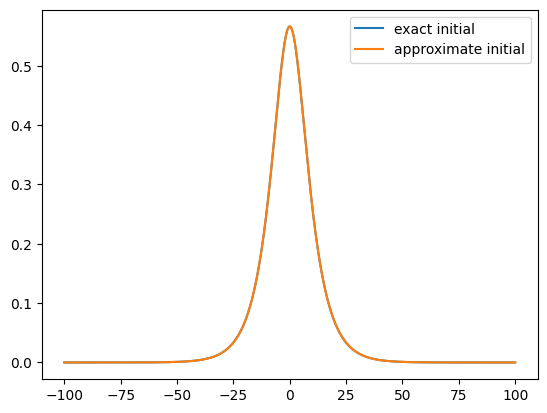

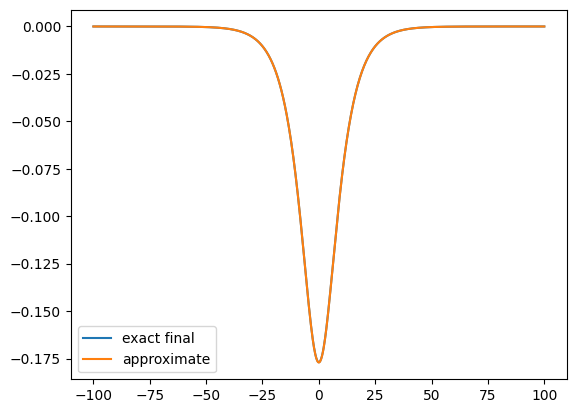

In [5]:
### SINE-GORDON: STATIONARY BREATHER ###
c_sine = 1
g_sine = lambda u : np.sin(u)
omega = 0.99
alpha = np.sqrt(1 - omega**2)
u_0_sine = lambda x : 4*np.arctan(alpha/(omega*np.cosh(alpha*x)))
v_0_sine = lambda x : 0
f_sine = lambda x,t : 0
L_sine = 100
T_sine = 2*np.pi/np.sqrt((np.pi**2 +1))
k_sine = 12
CFL_sine = 0.25

def u_sine_exact(x, t, omega=0.99):
        alpha = np.sqrt(1 - omega**2)
        u = 4 * np.arctan(
        (np.cos(omega * t) * alpha) /
        (omega * np.cosh(alpha * x))
        )
        return u
    
def compute_sine_errors(): 
    k_list = [8, 9, 10]
    h_list = []
    error_list = []
    rate_list = []
    for k in k_list:
        U =  solve_dispsersive_pde(L_sine, T_sine, k, c_sine, CFL_sine, u_0_sine, v_0_sine, g_sine, f_sine)

        # exact solution at the discrete grid points
        M = 2**k
        h = (2*L_sine) / (M)
        h_list.append(h)
        xs = [-L_sine + i * h for i in range(M + 1)]
        U_exact = [u_sine_exact(x,T_sine) for x in xs]
        U_initial = [u_sine_exact(x,0) for x in xs]

        E_M = max([abs(U_exact[i] - U[i, -1]) for i in range(M + 1)])
        error_list.append(E_M)
        # table entry
        print("{:e}\t{:e}".format(h, E_M))

    for j in [1,2]:
        r_k = np.log(error_list[j]/error_list[j-1])/np.log(h_list[j]/h_list[j-1])
        rate_list.append(r_k)

    print(rate_list)
    plt.plot(xs, U_initial, label="exact initial")
    plt.plot(xs, U[: , 0], label="approximate initial")
    plt.legend()
    plt.show()
    
    plt.plot(xs, U_exact, label="exact final")
    plt.plot(xs, U[: , -1], label="approximate")
    plt.legend()
    plt.show()
    

compute_sine_errors()